In [5]:
import tensorflow as tf
from tensorflow.keras.models import load_model
import pickle
import pandas as pd
import numpy as np

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
#load models.

model = load_model('/content/drive/MyDrive/ml_projects/DL_ANN_Binary_classification_project/artifacts/models/best_model.h5')

with open('/content/drive/MyDrive/ml_projects/DL_ANN_Binary_classification_project/onehot_encoder_geo.pkl', 'rb') as f:
    onehot_encoder_geo = pickle.load(f)
with open('/content/drive/MyDrive/ml_projects/DL_ANN_Binary_classification_project/label_encoder_gender.pkl', 'rb') as f:
    label_encoder_gender = pickle.load(f)
with open('/content/drive/MyDrive/ml_projects/DL_ANN_Binary_classification_project/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)



In [10]:
input_data = {
    'CreditScore': 619,
    'Geography': 'France',
    'Gender': 'Male',
    'Age': 42,
    'Tenure': 2,
    'Balance': 60000,
    'NumOfProducts': 1,
    'HasCrCard': 1,
    'IsActiveMember': 1,
    'EstimatedSalary': 50000
}

In [11]:
geo_encoded = onehot_encoder_geo.transform([[input_data['Geography']]]).toarray()
geo_encoded_df = pd.DataFrame(geo_encoded, columns=onehot_encoder_geo.get_feature_names_out(['Geography']))
geo_encoded_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0


In [12]:
input_df = pd.DataFrame([input_data])
input_df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Male,42,2,60000,1,1,1,50000


In [13]:
input_df['Gender'] = label_encoder_gender.transform(input_df['Gender'])
input_df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,1,42,2,60000,1,1,1,50000


In [ ]:
input_df = input_df.drop(['Geography'], axis=1)
input_df

In [15]:
input_df = pd.concat([input_df,geo_encoded_df], axis=1)
input_df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,619,1,42,2,60000,1,1,1,50000,1.0,0.0,0.0


In [16]:
input_scaled = scaler.transform(input_df)
input_scaled

array([[-0.33880827,  0.91324755,  0.29493847, -1.04241787, -0.25781119,
        -0.91668767,  0.64920267,  0.97481699, -0.87683221,  1.00150113,
        -0.57946723, -0.57638802]])

In [17]:
prediction = model.predict(input_scaled)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step


array([[0.3184812]], dtype=float32)

In [18]:
prediction_proba = prediction[0][0]
prediction_proba

np.float32(0.3184812)

In [19]:
if prediction_proba > 0.5:
  print('Customer will leave the bank')
else:
  print('Customer will not leave the bank')

Customer will not leave the bank


In [20]:
prediction_proba = float(prediction.squeeze())
prediction_label = int(prediction_proba >= 0.5)

In [21]:
prediction_proba

0.3184812068939209

In [22]:
prediction_label

0

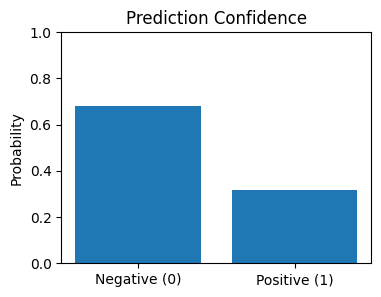

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 3))
plt.bar(["Negative (0)", "Positive (1)"],
        [1 - prediction_proba, prediction_proba])

plt.ylim(0, 1)
plt.ylabel("Probability")
plt.title("Prediction Confidence")
plt.show()

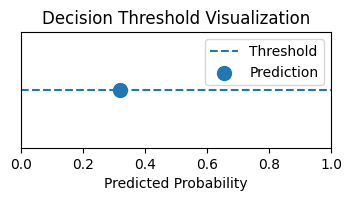

In [24]:
plt.figure(figsize=(4, 1.5))
plt.hlines(y=0.5, xmin=0, xmax=1, linestyles="--", label="Threshold")

plt.scatter(prediction_proba, 0.5, s=100, label="Prediction")
plt.xlim(0, 1)
plt.yticks([])
plt.xlabel("Predicted Probability")
plt.legend()
plt.title("Decision Threshold Visualization")
plt.show()